Mobina Haghshenas - 402125057

# Preprocessing



## Import Libraries

In [42]:
import math
import numpy as np
import pandas as pd
# import pandas_profiling as pp
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer,SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

# Classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn import metrics
from sklearn.metrics import confusion_matrix,recall_score,precision_score,f1_score,classification_report,accuracy_score,fbeta_score
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

import warnings
warnings.filterwarnings("ignore")

# Import the Dataset

In [2]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)


{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

In [3]:
df = pd.concat([X, y], axis=1)  #combine the given data
df.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [4]:
df.shape

(699, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Clump_thickness,699.0,4.417740,2.815741,1.0,2.0,4.0,6.0,10.0
Uniformity_of_cell_size,699.0,3.134478,3.051459,1.0,1.0,1.0,5.0,10.0
Uniformity_of_cell_shape,699.0,3.207439,2.971913,1.0,1.0,1.0,5.0,10.0
Marginal_adhesion,699.0,2.806867,2.855379,1.0,1.0,1.0,4.0,10.0
Single_epithelial_cell_size,699.0,3.216023,2.214300,1.0,2.0,2.0,4.0,10.0
Bare_nuclei,683.0,3.544656,3.643857,1.0,1.0,1.0,6.0,10.0
Bland_chromatin,699.0,3.437768,2.438364,1.0,2.0,3.0,5.0,10.0
Normal_nucleoli,699.0,2.866953,3.053634,1.0,1.0,1.0,4.0,10.0
Mitoses,699.0,1.589413,1.715078,1.0,1.0,1.0,1.0,10.0
Class,699.0,2.689557,0.951273,2.0,2.0,2.0,4.0,4.0


## Check for missing values

In [9]:
# Null values in the original dataset
df.isna().sum(axis=0)

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [11]:
for i in df.columns:
    print(i,len(df[df[i] == '?']))

Clump_thickness 0
Uniformity_of_cell_size 0
Uniformity_of_cell_shape 0
Marginal_adhesion 0
Single_epithelial_cell_size 0
Bare_nuclei 0
Bland_chromatin 0
Normal_nucleoli 0
Mitoses 0
Class 0


In [17]:
for i in df.columns:
    print(i,len(df[df[i] == 0]))

Clump_thickness 0
Uniformity_of_cell_size 0
Uniformity_of_cell_shape 0
Marginal_adhesion 0
Single_epithelial_cell_size 0
Bare_nuclei 0
Bland_chromatin 0
Normal_nucleoli 0
Mitoses 0
Class 0


In [13]:
# percent of missing "Bare_nuclei "
print('Percent of missing "Bare_nuclei" records is %.2f%%' %((df['Bare_nuclei'].isnull().sum()/df.shape[0])*100))

Percent of missing "Bare_nuclei " records is 2.29%


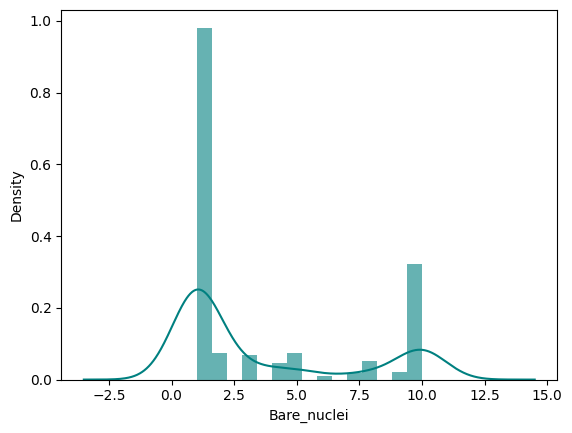

In [15]:
ax = df["Bare_nuclei"].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6)
df["Bare_nuclei"].plot(kind='density', color='teal')
ax.set(xlabel='Bare_nuclei')
plt.show()

In [18]:
#based on the distribution it is better to use median in this case!
df["Bare_nuclei"].fillna(df["Bare_nuclei"].median(skipna=True), inplace=True)
df.isna().sum(axis=0)

Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

## Check for Duplicate Rows

In [19]:
df.duplicated().sum()

242

In [20]:
df[df.duplicated()]

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
28,2,1,1,1,2,1.0,2,1,1,2
35,2,1,1,1,2,1.0,2,1,1,2
48,4,1,1,3,2,1.0,3,1,1,2
64,1,1,1,1,2,1.0,2,1,1,2
66,4,1,1,1,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
686,1,1,1,1,2,1.0,1,1,1,2
688,4,1,1,1,2,1.0,1,1,1,2
690,1,1,1,3,2,1.0,1,1,1,2
692,3,1,1,1,2,1.0,1,1,1,2


In [21]:
df= df.drop_duplicates()

## Check for Outlier

In [22]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum())

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size    30
Bare_nuclei                     0
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                        52
Class                           0
dtype: int64


In [25]:
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum())

Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


## Normalized dataset using MinMaxScaler


In [28]:
Min_Max_Scaled = MinMaxScaler().fit_transform(df)
df = pd.DataFrame(Min_Max_Scaled, columns = list(df.columns))

# Verify the normalization
print("Minimum values of features after min-max scaling:")
print( df.min())
print("\nMaximum values of features after min-max scaling:")
print(df.max())

Minimum values of features after min-max scaling:
Clump_thickness                0.0
Uniformity_of_cell_size        0.0
Uniformity_of_cell_shape       0.0
Marginal_adhesion              0.0
Single_epithelial_cell_size    0.0
Bare_nuclei                    0.0
Bland_chromatin                0.0
Normal_nucleoli                0.0
Mitoses                        0.0
Class                          0.0
dtype: float64

Maximum values of features after min-max scaling:
Clump_thickness                1.0
Uniformity_of_cell_size        1.0
Uniformity_of_cell_shape       1.0
Marginal_adhesion              1.0
Single_epithelial_cell_size    1.0
Bare_nuclei                    1.0
Bland_chromatin                1.0
Normal_nucleoli                1.0
Mitoses                        1.0
Class                          1.0
dtype: float64


## Stratified Train Test Split

In [29]:
Y = df['Class']
X = df.drop('Class', axis = 1)

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1, stratify=Y)

## Handling Data Imbalancing

In [34]:
print("Class 1 --> ", sum(Y == 1))
print("Class 0 --> ", sum(Y == 0))
print('Count of class 1 / count of class 0 -->', sum(Y == 1)/sum(Y == 0))

Class 1 -->  172
Class 0 -->  215
Count of class 1 / count of class 0 --> 0.8


In [32]:
print("Class 1 --> ", sum(Y_train == 1))
print("Class 0 --> ", sum(Y_train == 0))
print('Count of class 1 in the test data / count of class 0 in the test data -->', sum(Y_train == 1)/sum(Y_train == 0))

Class 1 -->  137
Class 0 -->  172
Count of class 1 in the test data / count of class 0 in the test data --> 0.7965116279069767


In [33]:
nr = NearMiss()

print("\nClass 1 before Under Sampling --> ", sum(Y_train == 1))
print("\nClass 0 before Under Sampling --> ", sum(Y_train == 0))


# X_train after Under Sampling --> X_train_US
# Y_train after Under Sampling --> Y_train_US
X_train_US, Y_train_US = nr.fit_resample(X_train, Y_train.ravel())

print("\nThe shape of the X after Under Sampling -->", X_train_US.shape)
print("\nThe shape of the Y after Under Sampling -->", Y_train_US.shape)

print("\nClass 1 after Under Sampling --> ", sum(Y_train_US == 1))
print("\nClass 0 after Under Sampling --> ", sum(Y_train_US == 0))
print("\n")


Class 1 before Under Sampling -->  137

Class 0 before Under Sampling -->  172

The shape of the X after Under Sampling --> (274, 9)

The shape of the Y after Under Sampling --> (274,)

Class 1 after Under Sampling -->  137

Class 0 after Under Sampling -->  137




In [36]:
X_train = X_train_US
Y_train = Y_train_US
X_train.shape

(274, 9)

In [38]:
X_test.shape

(78, 9)

# Perceptron

In [46]:
from sklearn.linear_model import Perceptron
Perceptron =Perceptron()

Perceptron.fit(X_train, Y_train)

y_predict = Perceptron.predict(X_test)

print('Test Accuracy -->', accuracy_score(Y_test, y_predict))
fpr, tpr, thresholds = metrics.roc_curve(Y_test, y_predict)
print('AUC -->',metrics.auc(fpr, tpr))
print('f1_score -->', f1_score(Y_test, y_predict))
print('f2_score -->',fbeta_score(Y_test, y_predict, average='macro', beta=0.5))
print('\nClassification_report:\n', classification_report(Y_test, y_predict))


confusion_matrix = metrics.confusion_matrix(Y_test, y_predict)
print('\nConfusion Matrix:\n', confusion_matrix)

CV = StratifiedKFold(n_splits = 7)
CV_scores = cross_val_score(Perceptron, X_train, Y_train, cv=CV)
CV_score_df = pd.DataFrame(CV_scores, columns = ['Accuracy'])
display(CV_score_df)
print('The Average of CV Scores -->', CV_score_df.Accuracy.mean())

Test Accuracy --> 0.9230769230769231
AUC --> 0.9196013289036545
f1_score --> 0.9117647058823529
f2_score --> 0.9237131118928064

Classification_report:
               precision    recall  f1-score   support

         0.0       0.91      0.95      0.93        43
         1.0       0.94      0.89      0.91        35

    accuracy                           0.92        78
   macro avg       0.93      0.92      0.92        78
weighted avg       0.92      0.92      0.92        78


Confusion Matrix:
 [[41  2]
 [ 4 31]]


,Accuracy
0,0.800000
1,0.743590
2,0.717949
3,0.948718
4,0.923077
5,0.974359
6,0.897436


The Average of CV Scores --> 0.857875457875458


# MLP

In [47]:
model_4 = MLPClassifier(hidden_layer_sizes=(8), activation='tanh', solver='adam',
                        learning_rate='constant', learning_rate_init=0.01,
                        max_iter=2000, early_stopping=False, verbose=False, random_state=42)
model_4.fit(X_train, Y_train)

y_predict_MLP = model_4.predict(X_test)

print('Test Accuracy -->', accuracy_score(Y_test, y_predict_MLP))
fpr, tpr, thresholds = metrics.roc_curve(Y_test, y_predict_MLP)
print('AUC -->',metrics.auc(fpr, tpr))
print('f1_score -->', f1_score(Y_test, y_predict_MLP))
print('f2_score -->',fbeta_score(Y_test, y_predict_MLP, average='macro', beta=0.5))
print('\nClassification_report:\n', classification_report(Y_test, y_predict_MLP))


confusion_matrix = metrics.confusion_matrix(Y_test, y_predict_MLP)
print('\nConfusion Matrix:\n', confusion_matrix)

CV = StratifiedKFold(n_splits = 7)
CV_scores = cross_val_score(Perceptron, X_train, Y_train, cv=CV)
CV_score_df = pd.DataFrame(CV_scores, columns = ['Accuracy'])
display(CV_score_df)
print('The Average of CV Scores -->', CV_score_df.Accuracy.mean())

Test Accuracy --> 0.8846153846153846
AUC --> 0.8794019933554817
f1_score --> 0.8656716417910447
f2_score --> 0.8853139104348531

Classification_report:
               precision    recall  f1-score   support

         0.0       0.87      0.93      0.90        43
         1.0       0.91      0.83      0.87        35

    accuracy                           0.88        78
   macro avg       0.89      0.88      0.88        78
weighted avg       0.89      0.88      0.88        78


Confusion Matrix:
 [[40  3]
 [ 6 29]]


,Accuracy
0,0.800000
1,0.743590
2,0.717949
3,0.948718
4,0.923077
5,0.974359
6,0.897436


The Average of CV Scores --> 0.857875457875458


# MLP Tuning

In [41]:
# Tuning

param_grid_mlp = {
    'hidden_layer_sizes': [(8), (20), (40), (4,4), (8,4,8)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'learning_rate':['constant', 'adaptive'],
    'learning_rate_init': [0.05, 0.01],
    'max_iter': [2000],
    'random_state': [42]}

CV = StratifiedKFold(n_splits = 7)
model = GridSearchCV(MLPClassifier(), param_grid_mlp, cv=CV,
                     scoring='accuracy',verbose=False)
model.fit(X_train, Y_train)
print(model.best_params_)

{'activation': 'relu', 'hidden_layer_sizes': 20, 'learning_rate': 'constant', 'learning_rate_init': 0.05, 'max_iter': 2000, 'random_state': 42, 'solver': 'sgd'}


In [48]:
model_5 = MLPClassifier(hidden_layer_sizes=model.best_params_['hidden_layer_sizes'], activation=model.best_params_['activation'],
                        solver=model.best_params_['solver'], learning_rate=model.best_params_['learning_rate'],
                        learning_rate_init=model.best_params_['learning_rate_init'], max_iter=model.best_params_['max_iter'],
                        random_state=42, verbose=False)
model_5.fit(X_train, Y_train)
y_predict_AFT = model_5.predict(X_test)

print('Test Accuracy -->', accuracy_score(Y_test, y_predict_AFT))
fpr, tpr, thresholds = metrics.roc_curve(Y_test, y_predict_AFT)
print('AUC -->',metrics.auc(fpr, tpr))
print('f1_score -->', f1_score(Y_test, y_predict_AFT))
print('f2_score -->',fbeta_score(Y_test, y_predict_AFT, average='macro', beta=0.5))
print('\nClassification_report:\n', classification_report(Y_test, y_predict_AFT))


confusion_matrix = metrics.confusion_matrix(Y_test, y_predict_AFT)
print('\nConfusion Matrix:\n', confusion_matrix)

CV = StratifiedKFold(n_splits = 7)
CV_scores = cross_val_score(Perceptron, X_train, Y_train, cv=CV)
CV_score_df = pd.DataFrame(CV_scores, columns = ['Accuracy'])
display(CV_score_df)
print('The Average of CV Scores -->', CV_score_df.Accuracy.mean())

Test Accuracy --> 0.9102564102564102
AUC --> 0.9106312292358804
f1_score --> 0.9014084507042254
f2_score --> 0.909012682358548

Classification_report:
               precision    recall  f1-score   support

         0.0       0.93      0.91      0.92        43
         1.0       0.89      0.91      0.90        35

    accuracy                           0.91        78
   macro avg       0.91      0.91      0.91        78
weighted avg       0.91      0.91      0.91        78


Confusion Matrix:
 [[39  4]
 [ 3 32]]


,Accuracy
0,0.800000
1,0.743590
2,0.717949
3,0.948718
4,0.923077
5,0.974359
6,0.897436


The Average of CV Scores --> 0.857875457875458
